In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
titanic_df = pd.read_csv("./Titanic-Dataset.csv")
titanic_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
heart_df = pd.read_csv("./heart.csv")
heart_df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [4]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
heart_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [6]:
numaric_cols = heart_df.select_dtypes(include=['int64', 'float64']).columns
numaric_cols

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

In [7]:
for col in numaric_cols:
    print(heart_df[col].head(2))

0    40
1    49
Name: Age, dtype: int64
0    140
1    160
Name: RestingBP, dtype: int64
0    289
1    180
Name: Cholesterol, dtype: int64
0    0
1    0
Name: FastingBS, dtype: int64
0    172
1    156
Name: MaxHR, dtype: int64
0    0.0
1    1.0
Name: Oldpeak, dtype: float64
0    0
1    1
Name: HeartDisease, dtype: int64


In [8]:
numaric_cols = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak",
]

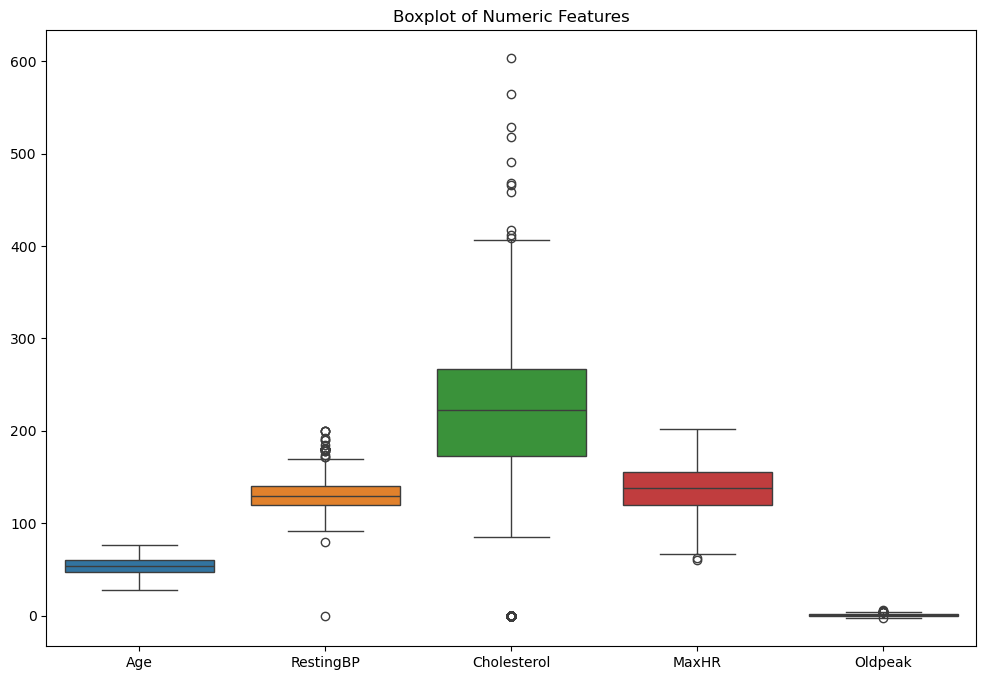

In [9]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=heart_df[numaric_cols])
plt.title("Boxplot of Numeric Features")
plt.show()

In [10]:
categorical_features = heart_df.select_dtypes(include=["object"]).columns.tolist()

In [11]:
categorical_features

['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

In [12]:
target = "HeartDisease"
if target in numaric_cols:
    numaric_cols.remove(target)

In [13]:
categorical_features = heart_df.select_dtypes(include=["object", "category"]).columns.tolist()
if target in categorical_features:
    categorical_features.remove(target)

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

X = heart_df.drop(columns=[target])
y = heart_df[target]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])

categorical_transformer = Pipeline(
    steps=[("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [15]:
X_processed = preprocessor.fit_transform(X)

print("Processed shape:", X_processed.shape)

Processed shape: (918, 15)


In [16]:
col = "Cholesterol"
Q1 = heart_df[col].quantile(0.25)
Q3 = heart_df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = heart_df[(heart_df[col] < lower) | (heart_df[col] > upper)]
print(f"Number of outliers in {col}: {outliers.shape[0]}")

Number of outliers in Cholesterol: 183


In [17]:
for col in numaric_cols:
    col = col
    Q1 = heart_df[col].quantile(0.25)
    Q3 = heart_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = heart_df[(heart_df[col] < lower) | (heart_df[col] > upper)]
    print(f"Number of outliers in {col}: {outliers.shape[0]}")

Number of outliers in Age: 0
Number of outliers in RestingBP: 28
Number of outliers in Cholesterol: 183
Number of outliers in MaxHR: 2
Number of outliers in Oldpeak: 16


In [18]:
#removing outliers
df_no_outliers = heart_df[(heart_df[col] >= lower) & (heart_df[col] <= upper)]

# cao outliers
df_capped = heart_df.copy()
df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

print("Original shape:", heart_df.shape)
print("Shape after removing outliers:", df_no_outliers.shape)
print("Shape after capping outliers:", df_capped.shape)

Original shape: (918, 12)
Shape after removing outliers: (902, 12)
Shape after capping outliers: (918, 12)


In [19]:
df_log = heart_df.copy()
df_log[col + "_log"] = np.log(df_log[col] + 1)  # Adding 1 to avoid log(0)
df_log.head()

c:\Users\abdul\anaconda3\envs\dataS\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\abdul\anaconda3\envs\dataS\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Oldpeak_log
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,0.000000
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,0.693147
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,0.000000
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,0.916291
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,0.000000


In [20]:
df_log.shape

(918, 13)

In [21]:
col

'Oldpeak'

In [22]:
heart_df[col]

0      0.0
1      1.0
2      0.0
3      1.5
4      0.0
      ... 
913    1.2
914    3.4
915    1.2
916    0.0
917    0.0
Name: Oldpeak, Length: 918, dtype: float64

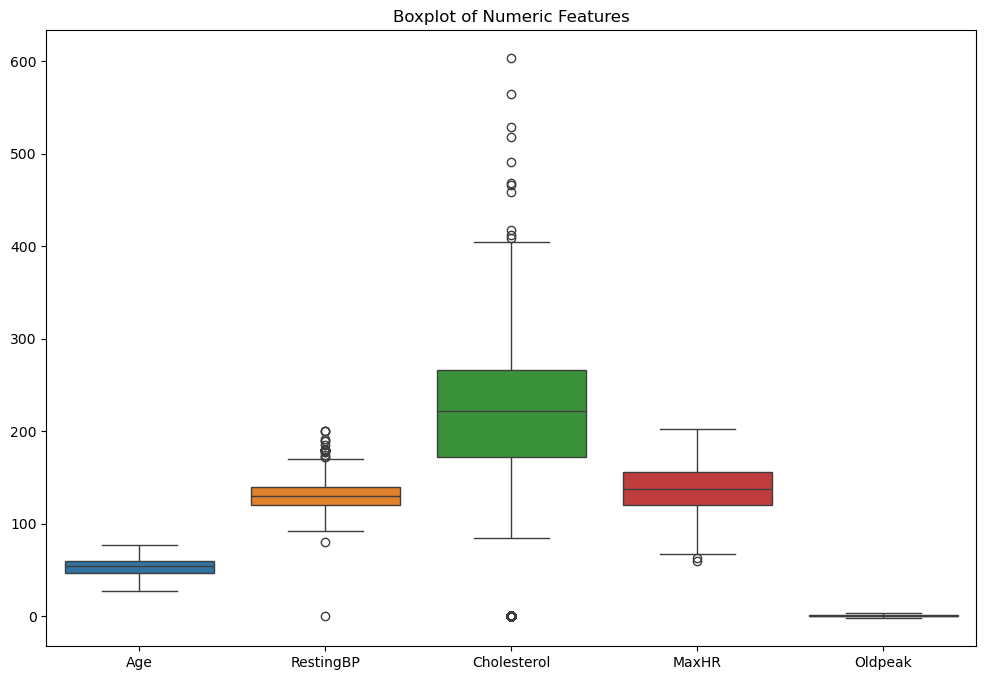

In [24]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_no_outliers[numaric_cols])
plt.title("Boxplot of Numeric Features")
plt.show()

In [28]:
# for col in numaric_cols:
#     #removing outliers
#     df_no_outliers = heart_df[(heart_df[col] >= lower) & (heart_df[col] <= upper)]

#     # cao outliers
#     df_capped = heart_df.copy()
#     df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
#     print(f"Processing column: {col}")
#     print("Original shape:", heart_df.shape)
#     print("Shape after removing outliers:", df_no_outliers.shape)
#     print("Shape after capping outliers:", df_capped.shape)
#     print("-" * 40)

Processing column: Age
Original shape: (918, 12)
Shape after removing outliers: (0, 12)
Shape after capping outliers: (918, 12)
----------------------------------------
Processing column: RestingBP
Original shape: (918, 12)
Shape after removing outliers: (1, 12)
Shape after capping outliers: (918, 12)
----------------------------------------
Processing column: Cholesterol
Original shape: (918, 12)
Shape after removing outliers: (172, 12)
Shape after capping outliers: (918, 12)
----------------------------------------
Processing column: MaxHR
Original shape: (918, 12)
Shape after removing outliers: (0, 12)
Shape after capping outliers: (918, 12)
----------------------------------------
Processing column: Oldpeak
Original shape: (918, 12)
Shape after removing outliers: (902, 12)
Shape after capping outliers: (918, 12)
----------------------------------------


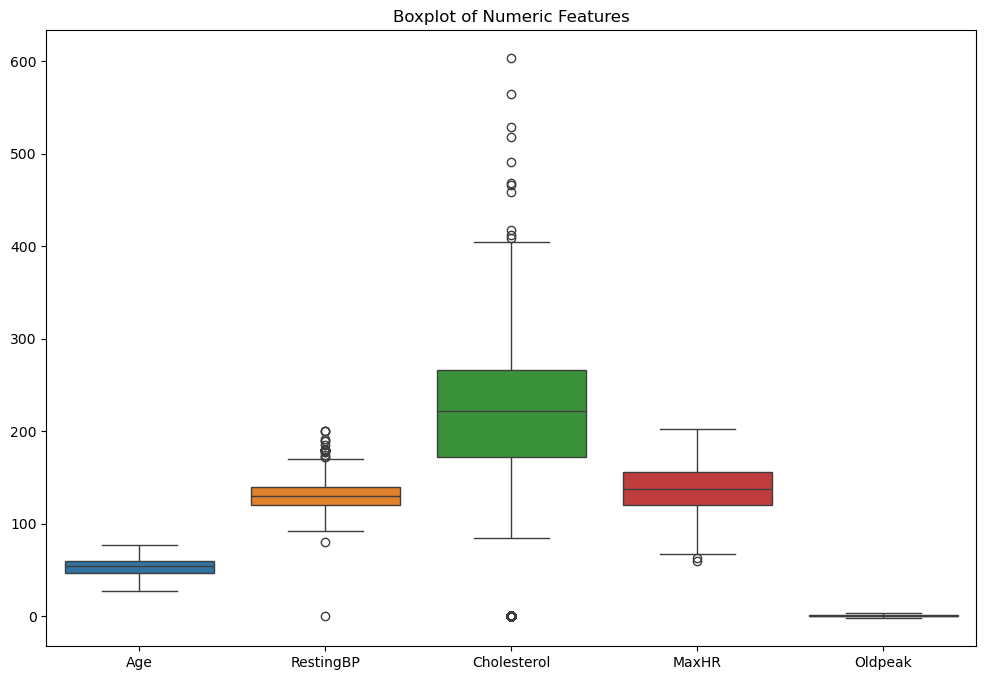

In [29]:
# plt.figure(figsize=(12, 8))
# sns.boxplot(data=df_no_outliers[numaric_cols])
# plt.title("Boxplot of Numeric Features")
# plt.show()